# House Price Prediction - Regression Project
**Name:** Jatin  
**Subject:** Machine Learning  
**Dataset:** Advanced Regression HousePrice Dataset (3800 rows)

## Theory Questions

**Q1. What is Regularization? Why do we use it?**

Regularization is a way to stop the model from overfitting. When we train a model too much on training data, it memorizes the data instead of learning general patterns. To fix this, regularization adds a penalty to the model so it doesn't grow too complex.

Example: If I study only the exact questions from last year's paper, I'll fail if the questions change slightly. But if I understand the concept, I'll do better. Regularization is like making the model understand the concept.

---

**Q2. Difference between Ridge (L2) and Lasso (L1)**

Both are types of regularization but they work differently:

- **Ridge (L2):** Adds the square of the coefficients as penalty. It makes coefficients small but never exactly zero. So all features are kept.
- **Lasso (L1):** Adds the absolute value of coefficients as penalty. It can make some coefficients exactly zero. So it removes useless features automatically.

I think of it like this: Ridge shrinks all features a little. Lasso throws out the least important ones completely.

---

**Q3. What is Cross Validation?**

Cross Validation is a technique to test how well our model works on unseen data. Instead of using just one train-test split, we split the data multiple times and average the results.

Why it is useful: A single train-test split can be lucky or unlucky depending on which rows go into train vs test. Cross validation removes that luck factor.

---

**Q4. Types of Cross Validation**

1. **K-Fold CV:** Divide data into K parts. Train on K-1 parts, test on 1 part. Do this K times.
2. **Stratified K-Fold:** Same as K-Fold but keeps the class balance same in each fold. Useful for classification with imbalanced data.
3. **Leave One Out (LOO):** K = total number of rows. Train on all rows except 1, test on that 1 row. Very slow for large datasets.
4. **TimeSeriesSplit:** For time-ordered data. Training set always comes before test set. We cannot use future data to predict past.

---

**Q5. Why don't tree-based models need feature scaling?**

Tree models like Decision Tree and Random Forest work by asking questions like "is area > 1500?". These comparisons are based on order of values, not the actual numbers. So whether area is in sqft or in some other unit, the order stays the same and the split stays the same.

But models like Ridge, Lasso need scaling because they calculate distances and gradients — those depend on the actual number values.

---
## Part B: Loading and Understanding the Dataset

In [1]:
# importing the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('libraries loaded')

libraries loaded


In [4]:
# loading the dataset
df = pd.read_csv('Advanced_Regression_HousePrice_Dataset_3800.csv.csv')
print('shape of dataset:', df.shape)

shape of dataset: (3800, 12)


In [5]:
# looking at first 5 rows
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [6]:
# checking data types and null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB
None


In [7]:
# checking for missing values
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64


In [8]:
# basic statistics
df.describe().round(2)

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00
mean,201900.50,1716.93,3.43,2.92,6.50,22.54,13.09,0.55,0.47,4.24,20719397.17
std,1097.11,583.00,1.36,1.13,1.77,12.33,6.54,0.50,0.50,2.05,8707465.39
min,200001.00,500.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.50,1506126.00
25%,200950.75,1322.00,2.00,2.00,5.30,14.00,8.50,0.00,0.00,2.81,14468946.50
50%,201900.50,1700.50,3.00,3.00,6.50,20.00,13.00,1.00,0.00,4.22,19891801.50
75%,202850.25,2105.00,4.00,4.00,7.70,29.00,17.50,1.00,1.00,5.65,25960617.50
max,203800.00,3776.00,7.00,6.00,10.00,80.00,38.70,1.00,1.00,12.00,59303146.00


**Observation:** There are 3800 rows and 12 columns. No missing values. The target column is `house_price_inr`. Columns like `property_id` and `sale_date` are not useful for prediction so I will drop them.

In [9]:
# dropping columns that are not useful
df = df.drop(columns=['property_id', 'sale_date'])
print('columns after dropping:', df.columns.tolist())

columns after dropping: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']


In [10]:
# separating features and target
X = df.drop(columns=['house_price_inr'])
y = df['house_price_inr']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Features:', X.columns.tolist())

X shape: (3800, 9)
y shape: (3800,)
Features: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']


## Part C: Exploratory Data Analysis (EDA)

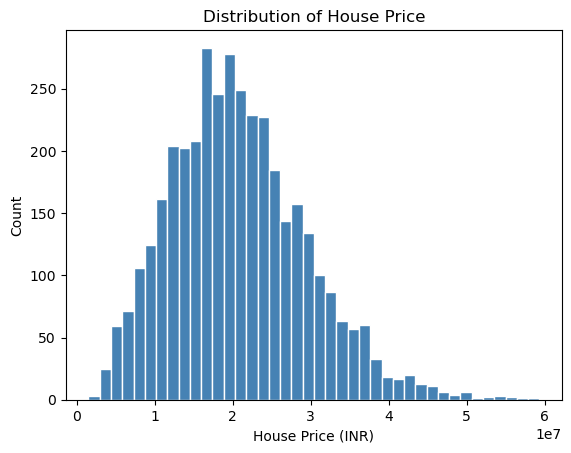

The distribution looks slightly right skewed


In [17]:
# plotting distribution of the target variable
plt.hist(y, bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of House Price')
plt.xlabel('House Price (INR)')
plt.ylabel('Count')
plt.show()
print('The distribution looks slightly right skewed')

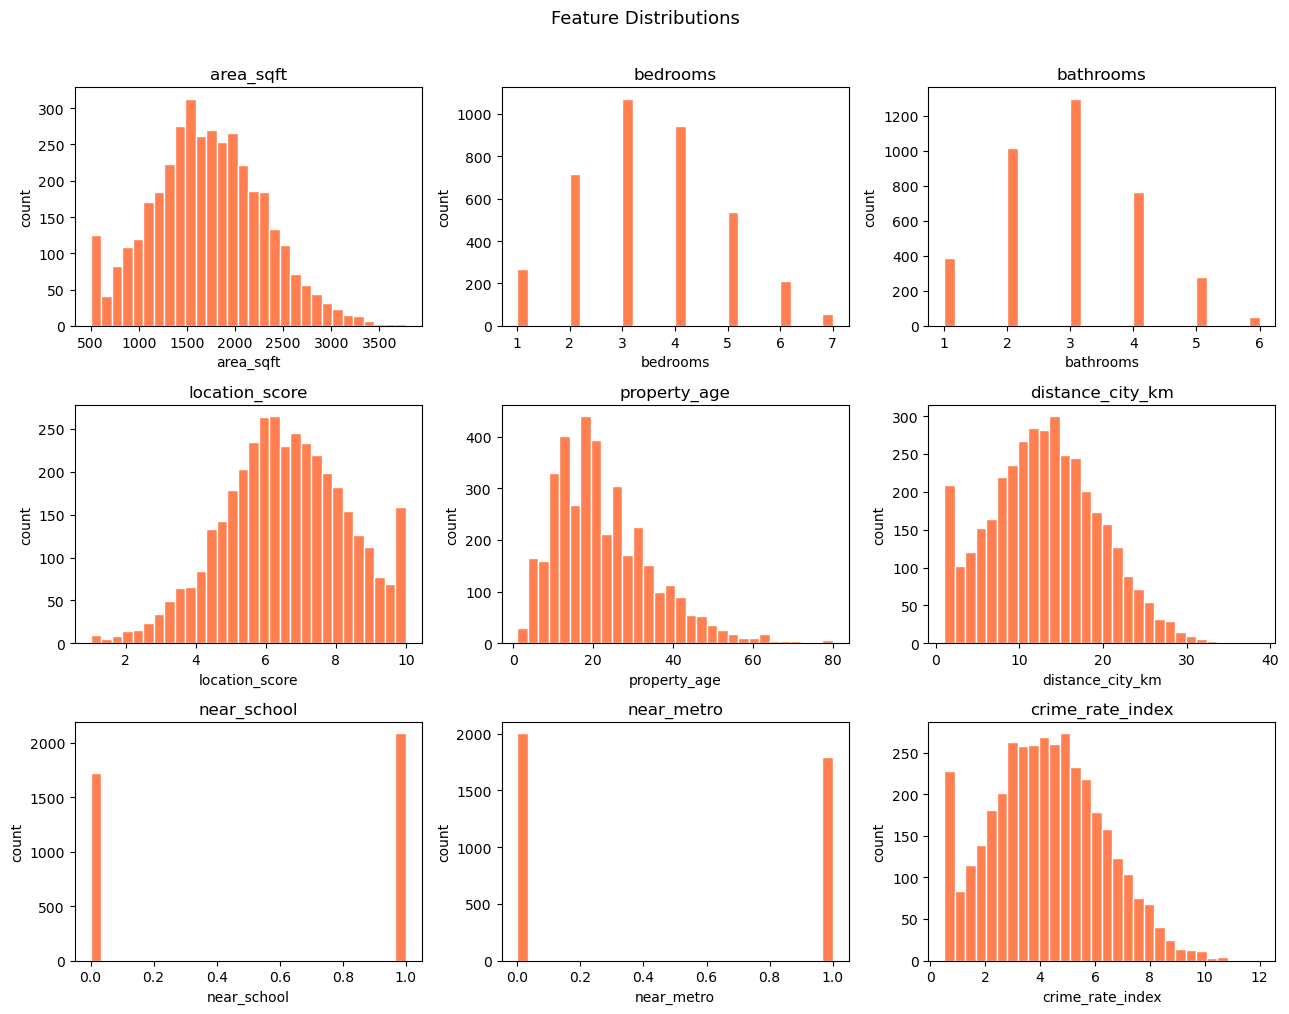

In [19]:
# plotting each feature
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, color='coral', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

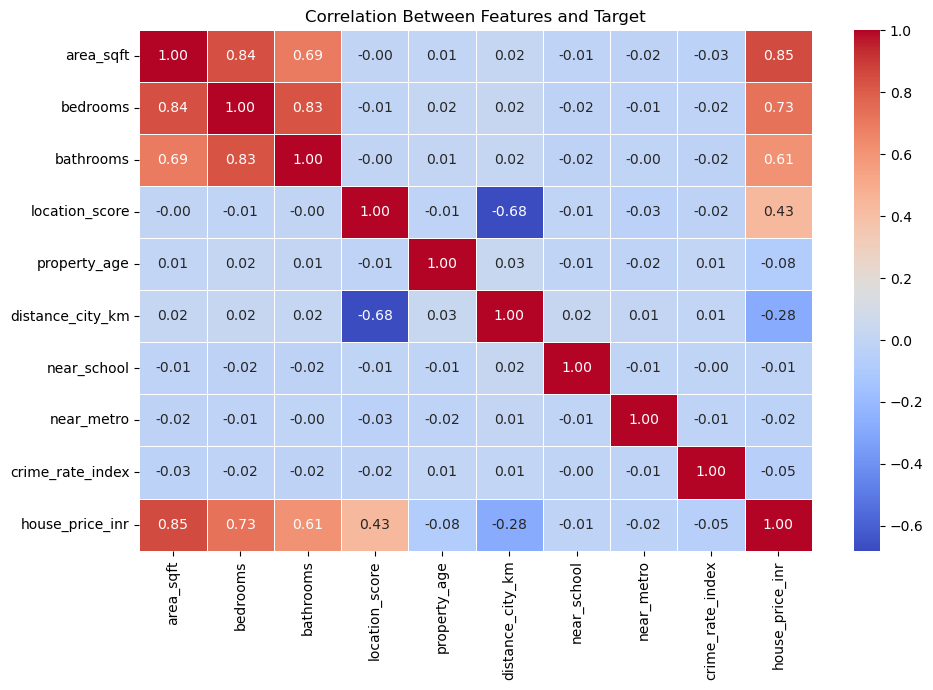

Observation: area_sqft and bedrooms have highest positive correlation with price
crime_rate_index has negative correlation with price - makes sense


In [20]:
# correlation heatmap - to see which features are related to house price
plt.figure(figsize=(10, 7))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Features and Target')
plt.tight_layout()
plt.show()
print('Observation: area_sqft and bedrooms have highest positive correlation with price')
print('crime_rate_index has negative correlation with price - makes sense')

## Part D: Train-Test Split and Scaling

In [21]:
# splitting into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 3040
Testing samples: 760


In [22]:
# applying standard scaler - needed for Ridge and Lasso
# fit only on training data, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling done')
print('Note: we fit scaler only on X_train to avoid data leakage')

Scaling done
Note: we fit scaler only on X_train to avoid data leakage


## Part E: Ridge Regression (L2)

In [23]:
# training Ridge model
# alpha is the regularization strength - I will try a few values manually
ridge_model = Ridge(alpha=100)
ridge_model.fit(X_train_scaled, y_train)

# predictions
y_pred_train_ridge = ridge_model.predict(X_train_scaled)
y_pred_test_ridge = ridge_model.predict(X_test_scaled)

# metrics
train_r2 = r2_score(y_train, y_pred_train_ridge)
test_r2 = r2_score(y_test, y_pred_test_ridge)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print('--- Ridge Regression Results (alpha=100) ---')
print(f'Train R2  : {train_r2:.4f}')
print(f'Test  R2  : {test_r2:.4f}')
print(f'Train RMSE: {train_rmse:,.0f}')
print(f'Test  RMSE: {test_rmse:,.0f}')

--- Ridge Regression Results (alpha=100) ---
Train R2  : 0.9143
Test  R2  : 0.9156
Train RMSE: 2,528,345
Test  RMSE: 2,607,897


In [24]:
# trying different alpha values for Ridge to see which is best
alphas_to_try = [0.01, 0.1, 1, 10, 100, 500, 1000, 5000]
r2_scores = []

for a in alphas_to_try:
    m = Ridge(alpha=a)
    m.fit(X_train_scaled, y_train)
    score = r2_score(y_test, m.predict(X_test_scaled))
    r2_scores.append(score)
    print(f'alpha={a:>6} | Test R2 = {score:.4f}')

best_alpha_ridge = alphas_to_try[r2_scores.index(max(r2_scores))]
print(f'\nBest alpha for Ridge: {best_alpha_ridge}')

alpha=  0.01 | Test R2 = 0.9187
alpha=   0.1 | Test R2 = 0.9187
alpha=     1 | Test R2 = 0.9187
alpha=    10 | Test R2 = 0.9185
alpha=   100 | Test R2 = 0.9156
alpha=   500 | Test R2 = 0.8933
alpha=  1000 | Test R2 = 0.8635
alpha=  5000 | Test R2 = 0.6768

Best alpha for Ridge: 0.01


In [25]:
# final ridge model with best alpha
ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_train_scaled, y_train)

# ridge coefficients - which features matter most
coef_df = pd.DataFrame({'Feature': X.columns, 'Ridge Coefficient': ridge_final.coef_})
coef_df = coef_df.sort_values('Ridge Coefficient', ascending=False)
print(coef_df.to_string(index=False))

         Feature  Ridge Coefficient
       area_sqft       6.944823e+06
  location_score       3.678947e+06
        bedrooms       2.912634e+05
       bathrooms       2.854311e+05
      near_metro       5.829633e+04
     near_school       1.690766e+04
distance_city_km      -2.881391e+04
crime_rate_index      -1.354026e+05
    property_age      -6.514815e+05


## Part F: Lasso Regression (L1)

In [26]:
# training Lasso model
# Lasso can make coefficients zero - so it does feature selection too
alphas_to_try_lasso = [0.01, 0.1, 1, 10, 50, 100, 500]
lasso_r2_scores = []

for a in alphas_to_try_lasso:
    m = Lasso(alpha=a, max_iter=5000)
    m.fit(X_train_scaled, y_train)
    score = r2_score(y_test, m.predict(X_test_scaled))
    lasso_r2_scores.append(score)
    print(f'alpha={a:>5} | Test R2 = {score:.4f}')

best_alpha_lasso = alphas_to_try_lasso[lasso_r2_scores.index(max(lasso_r2_scores))]
print(f'\nBest alpha for Lasso: {best_alpha_lasso}')

alpha= 0.01 | Test R2 = 0.9187
alpha=  0.1 | Test R2 = 0.9187
alpha=    1 | Test R2 = 0.9187
alpha=   10 | Test R2 = 0.9187
alpha=   50 | Test R2 = 0.9187
alpha=  100 | Test R2 = 0.9187
alpha=  500 | Test R2 = 0.9187

Best alpha for Lasso: 0.01


In [27]:
# final lasso model
lasso_final = Lasso(alpha=best_alpha_lasso, max_iter=5000)
lasso_final.fit(X_train_scaled, y_train)

# checking which features lasso set to zero
lasso_coef_df = pd.DataFrame({'Feature': X.columns, 'Lasso Coefficient': lasso_final.coef_})
print(lasso_coef_df.to_string(index=False))

zero_features = lasso_coef_df[lasso_coef_df['Lasso Coefficient'] == 0]['Feature'].tolist()
print(f'\nFeatures removed by Lasso (coef = 0): {zero_features}')

         Feature  Lasso Coefficient
       area_sqft       6.944896e+06
        bedrooms       2.912015e+05
       bathrooms       2.854322e+05
  location_score       3.678968e+06
    property_age      -6.514833e+05
distance_city_km      -2.880019e+04
     near_school       1.690700e+04
      near_metro       5.829725e+04
crime_rate_index      -1.354019e+05

Features removed by Lasso (coef = 0): []


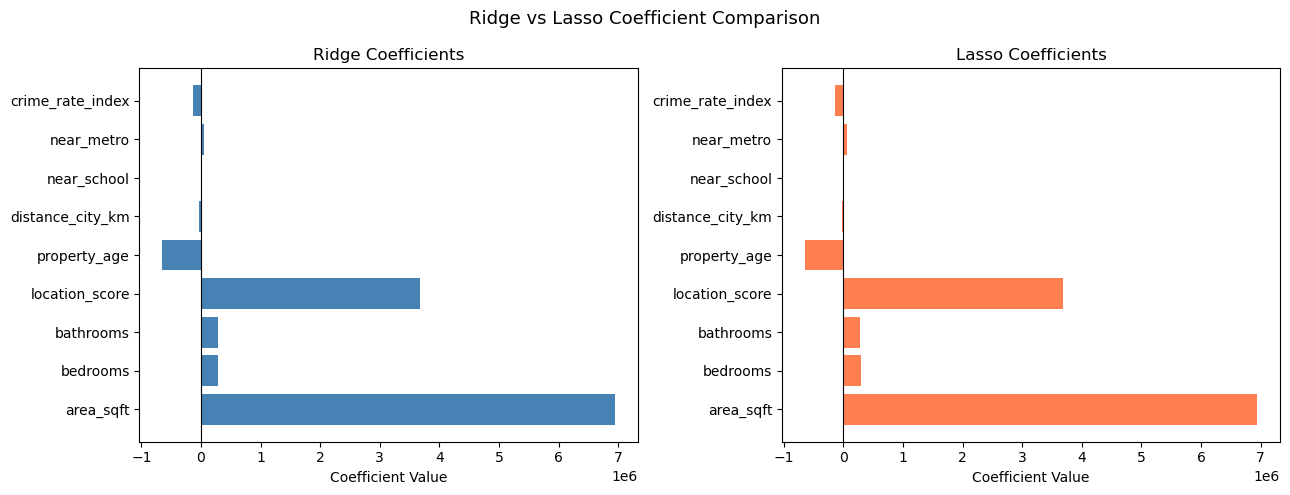

Observation: Lasso sets some coefficients to exactly zero. Ridge keeps all features but shrinks them.


In [28]:
# Ridge vs Lasso coefficient comparison chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(X.columns, ridge_final.coef_, color='steelblue')
axes[0].set_title('Ridge Coefficients')
axes[0].set_xlabel('Coefficient Value')
axes[0].axvline(x=0, color='black', linewidth=0.8)

axes[1].barh(X.columns, lasso_final.coef_, color='coral')
axes[1].set_title('Lasso Coefficients')
axes[1].set_xlabel('Coefficient Value')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Ridge vs Lasso Coefficient Comparison', fontsize=13)
plt.tight_layout()
plt.show()
print('Observation: Lasso sets some coefficients to exactly zero. Ridge keeps all features but shrinks them.')

## Part G: Cross Validation

In [29]:
# K-Fold Cross Validation on Ridge model
# I am using 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(Ridge(alpha=best_alpha_ridge), X_train_scaled, y_train, cv=kf, scoring='r2')

print('CV R2 scores for each fold:', cv_scores.round(4))
print(f'Mean CV R2: {cv_scores.mean():.4f}')
print(f'Std of CV R2: {cv_scores.std():.4f}')
print('\nLow std means the model is consistent across folds - good sign')

CV R2 scores for each fold: [0.9172 0.9071 0.9147 0.9197 0.9174]
Mean CV R2: 0.9152
Std of CV R2: 0.0044

Low std means the model is consistent across folds - good sign


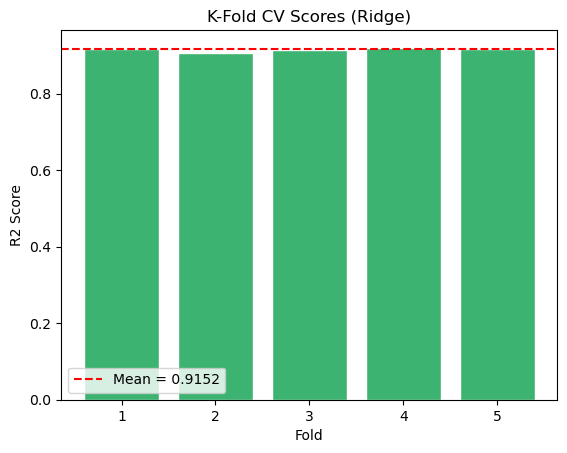

In [31]:
# plotting the fold scores to visualize variation
plt.bar(range(1, 6), cv_scores, color='mediumseagreen', edgecolor='white')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title('K-Fold CV Scores (Ridge)')
plt.xlabel('Fold')
plt.ylabel('R2 Score')
plt.legend()
plt.show()

## Part H: Tree-Based Models

In [32]:
# Decision Tree Regressor
# No scaling needed for tree models
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print('Decision Tree (max_depth=6):')
print(f'Test R2  : {dt_r2:.4f}')
print(f'Test RMSE: {dt_rmse:,.0f}')

Decision Tree (max_depth=6):
Test R2  : 0.8986
Test RMSE: 2,857,976


In [33]:
# Random Forest Regressor
# Random forest uses many trees and averages their predictions
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('Random Forest (100 trees, max_depth=10):')
print(f'Test R2  : {rf_r2:.4f}')
print(f'Test RMSE: {rf_rmse:,.0f}')

Random Forest (100 trees, max_depth=10):
Test R2  : 0.9286
Test RMSE: 2,397,950


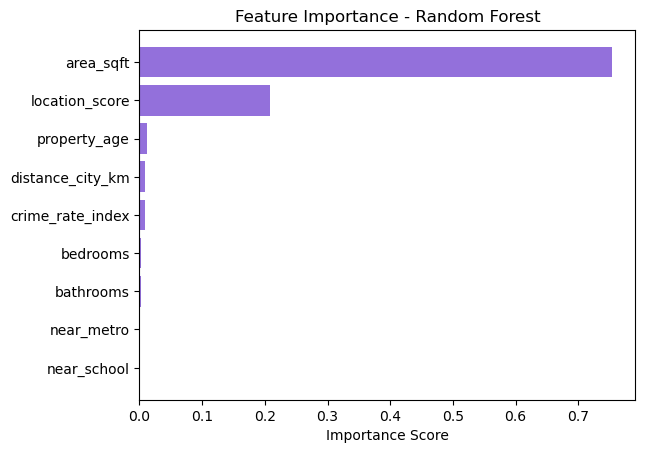

Top 3 important features:
       Feature  Importance
     area_sqft    0.753529
location_score    0.208793
  property_age    0.011959


In [35]:
# feature importance from Random Forest
fi = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
fi = fi.sort_values('Importance', ascending=False)

plt.barh(fi['Feature'], fi['Importance'], color='mediumpurple')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

print('Top 3 important features:')
print(fi.head(3).to_string(index=False))

## Part I: Final Comparison of All Models

In [36]:
# comparing all models together

# getting predictions for ridge and lasso
y_pred_ridge = ridge_final.predict(X_test_scaled)
y_pred_lasso = lasso_final.predict(X_test_scaled)

model_names = ['Ridge', 'Lasso', 'Decision Tree', 'Random Forest']
predictions = [y_pred_ridge, y_pred_lasso, y_pred_dt, y_pred_rf]

print(f'{"Model":<20} {"Test R2":>10} {"Test RMSE":>15} {"Test MAE":>15}')
print('-' * 62)

results = []
for name, pred in zip(model_names, predictions):
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
    print(f'{name:<20} {r2:>10.4f} {rmse:>15,.0f} {mae:>15,.0f}')

Model                   Test R2       Test RMSE        Test MAE
--------------------------------------------------------------
Ridge                    0.9187       2,558,126       1,959,377
Lasso                    0.9187       2,558,123       1,959,378
Decision Tree            0.8986       2,857,976       2,104,749
Random Forest            0.9286       2,397,950       1,764,644


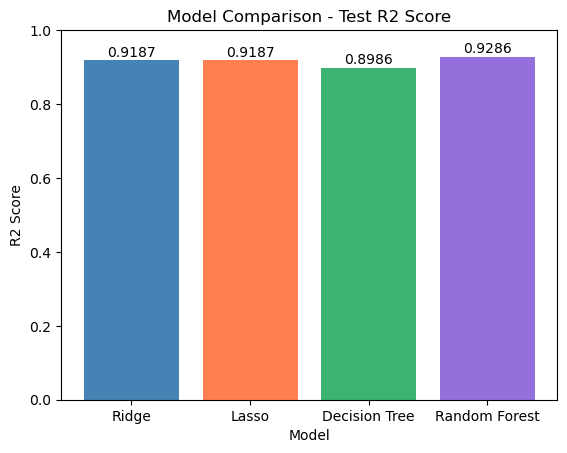

In [38]:
# bar chart comparing R2 scores
results_df = pd.DataFrame(results)

plt.bar(results_df['Model'], results_df['R2'], color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
plt.title('Model Comparison - Test R2 Score')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
for i, v in enumerate(results_df['R2']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
plt.show()

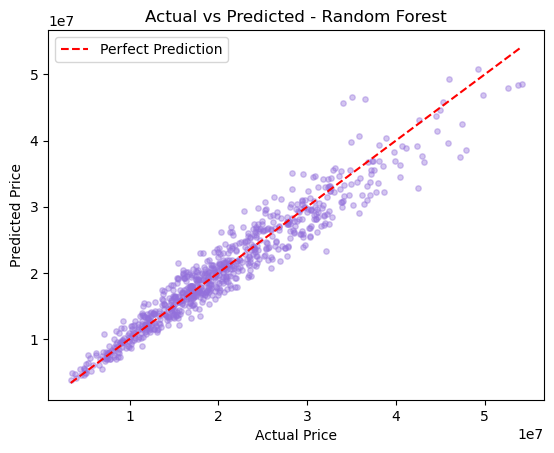

Points close to the red line = good predictions


In [40]:
# actual vs predicted plot for Random Forest (best model)
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='mediumpurple', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()
print('Points close to the red line = good predictions')

## Conclusion

In this project I built 4 regression models to predict house prices.

- Ridge and Lasso are linear models with regularization. They work well but have lower R2 than tree models.
- Lasso showed feature selection capability - some coefficients became exactly 0.
- Random Forest gave the best R2 score because it uses many trees and handles nonlinear patterns better.
- The most important features for predicting price were `area_sqft`, `location_score`, and `bedrooms`.
- Cross validation showed the Ridge model gives consistent results across different data splits.

**Best model: Random Forest** - it had the highest R2 and lowest RMSE.